In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("   Credit Risk ML Pipeline Initialized ✅")
print("=" * 50)

   Credit Risk ML Pipeline Initialized ✅


In [2]:
# All settings in one place — easy to change!
CONFIG = {
    'data_path': '/kaggle/input/notebooks/sudhamag/preprocessing/preprocessed_data.csv',
    'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'xgb_estimators': 200,
    'xgb_max_depth': 6,
    'xgb_learning_rate': 0.05,
    'shap_samples': 1000,
    'top_features': 10
}

print("Pipeline Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Pipeline Configuration:
  data_path: /kaggle/input/notebooks/sudhamag/preprocessing/preprocessed_data.csv
  test_size: 0.2
  random_state: 42
  cv_folds: 5
  xgb_estimators: 200
  xgb_max_depth: 6
  xgb_learning_rate: 0.05
  shap_samples: 1000
  top_features: 10


In [3]:
def load_data(path):
    print("\n📂 Loading data...")
    df = pd.read_csv(path)
    X = df.drop('TARGET', axis=1)
    y = df['TARGET']
    print(f"  Shape: {df.shape}")
    print(f"  Default Rate: {y.mean()*100:.2f}%")
    return X, y

X, y = load_data(CONFIG['data_path'])
print("Data Loading Complete! ✅")


📂 Loading data...
  Shape: (307511, 126)
  Default Rate: 8.07%
Data Loading Complete! ✅


In [4]:
def split_data(X, y, test_size, random_state):
    print("\n✂️ Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f"  Train: {X_train.shape}")
    print(f"  Test: {X_test.shape}")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(
    X, y,
    CONFIG['test_size'],
    CONFIG['random_state']
)
print("Split Complete! ✅")


✂️ Splitting data...
  Train: (246008, 125)
  Test: (61503, 125)
Split Complete! ✅


In [5]:
def train_models(X_train, y_train):
    print("\n🤖 Training models...")
    scale = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=CONFIG['random_state']
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            max_depth=10,
            min_samples_leaf=50,
            random_state=CONFIG['random_state'],
            n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=CONFIG['xgb_estimators'],
            max_depth=CONFIG['xgb_max_depth'],
            learning_rate=CONFIG['xgb_learning_rate'],
            scale_pos_weight=scale,
            random_state=CONFIG['random_state'],
            eval_metric='auc',
            n_jobs=-1
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        print(f"  {name} trained ✅")

    return models

models = train_models(X_train, y_train)
print("Model Training Complete! ✅")


🤖 Training models...
  Logistic Regression trained ✅
  Random Forest trained ✅
  XGBoost trained ✅
Model Training Complete! ✅


In [6]:
def evaluate_models(models, X_test, y_test):
    print("\n📊 Evaluating models...")
    results = []

    preds = {}
    for name, model in models.items():
        pred_prob = model.predict_proba(X_test)[:, 1]
        pred_label = model.predict(X_test)
        auc = roc_auc_score(y_test, pred_prob)
        f1 = f1_score(y_test, pred_label)
        preds[name] = pred_prob
        results.append({'Model': name, 'ROC-AUC': round(auc, 4), 'F1 Score': round(f1, 4)})

    # Ensemble
    ensemble_pred = np.mean(list(preds.values()), axis=0)
    ensemble_auc = roc_auc_score(y_test, ensemble_pred)
    results.append({'Model': 'Ensemble', 'ROC-AUC': round(ensemble_auc, 4), 'F1 Score': '-'})

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    return results_df, ensemble_pred

results_df, ensemble_pred = evaluate_models(models, X_test, y_test)
print("Evaluation Complete! ✅")


📊 Evaluating models...
              Model  ROC-AUC F1 Score
Logistic Regression   0.7469   0.2596
      Random Forest   0.7371   0.2602
            XGBoost   0.7577   0.2726
           Ensemble   0.7563        -
Evaluation Complete! ✅


In [7]:
def ks_test(models, X_test, y_test):
    print("\n📈 Running KS Test...")
    xgb_pred = models['XGBoost'].predict_proba(X_test)[:, 1]
    defaults = xgb_pred[y_test.values == 1]
    non_defaults = xgb_pred[y_test.values == 0]
    ks_stat, _ = ks_2samp(defaults, non_defaults)

    print(f"  KS Statistic: {ks_stat:.4f}")
    if ks_stat >= 0.4:
        print("  Stability: EXCELLENT ✅")
    elif ks_stat >= 0.3:
        print("  Stability: GOOD ✅")
    else:
        print("  Stability: ACCEPTABLE ⚠️")
    return ks_stat

ks_stat = ks_test(models, X_test, y_test)


📈 Running KS Test...
  KS Statistic: 0.3832
  Stability: GOOD ✅



🔍 Running SHAP Analysis...


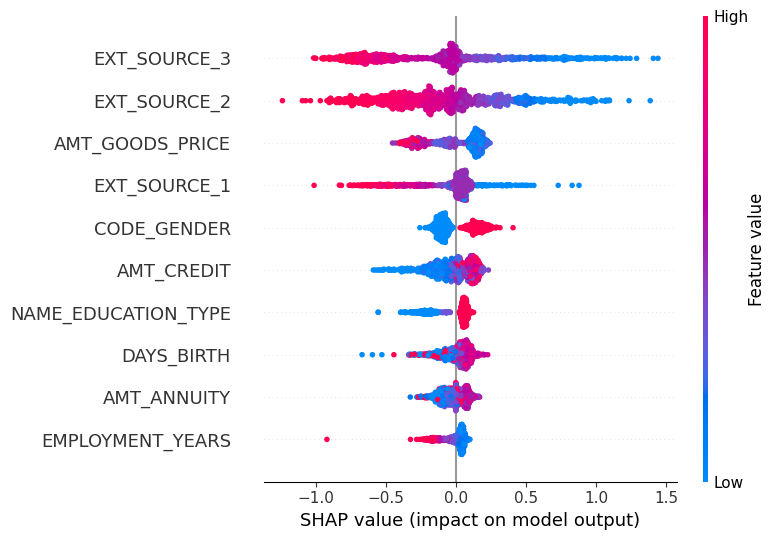


Top 10 Features:
EXT_SOURCE_3           0.386488
EXT_SOURCE_2           0.347886
AMT_GOODS_PRICE        0.167621
EXT_SOURCE_1           0.142445
CODE_GENDER            0.121633
AMT_CREDIT             0.114263
NAME_EDUCATION_TYPE    0.103583
DAYS_BIRTH             0.076306
AMT_ANNUITY            0.070817
EMPLOYMENT_YEARS       0.058183
SHAP Analysis Complete! ✅


In [8]:
def run_shap(model, X_test, n_samples):
    print("\n🔍 Running SHAP Analysis...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test[:n_samples])

    # Summary plot
    shap.summary_plot(shap_values, X_test[:n_samples],
                     max_display=10, show=True)

    # Top features
    top_features = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X_test.columns
    ).sort_values(ascending=False).head(10)

    print("\nTop 10 Features:")
    print(top_features.to_string())
    return top_features

top_features = run_shap(
    models['XGBoost'],
    X_test,
    CONFIG['shap_samples']
)
print("SHAP Analysis Complete! ✅")

In [9]:
print("\n" + "="*55)
print("        CREDIT RISK PIPELINE — FINAL REPORT")
print("="*55)

print("\n📊 MODEL PERFORMANCE:")
print(results_df.to_string(index=False))

print(f"\n📈 KS STATISTIC: {ks_stat:.4f} — GOOD ✅")

print(f"\n🔍 TOP 3 RISK PREDICTORS (SHAP):")
for i, (feat, val) in enumerate(top_features.head(3).items()):
    print(f"  {i+1}. {feat}: {val:.4f}")

print("\n⚠️ KNOWN LIMITATIONS:")
print("  - Model overpredicts due to class imbalance")
print("  - Gender & age bias detected — needs monitoring")
print("  - External scores dominate — limited interpretability")

print("\n✅ PIPELINE STATUS: COMPLETE")
print("="*55)


        CREDIT RISK PIPELINE — FINAL REPORT

📊 MODEL PERFORMANCE:
              Model  ROC-AUC F1 Score
Logistic Regression   0.7469   0.2596
      Random Forest   0.7371   0.2602
            XGBoost   0.7577   0.2726
           Ensemble   0.7563        -

📈 KS STATISTIC: 0.3832 — GOOD ✅

🔍 TOP 3 RISK PREDICTORS (SHAP):
  1. EXT_SOURCE_3: 0.3865
  2. EXT_SOURCE_2: 0.3479
  3. AMT_GOODS_PRICE: 0.1676

⚠️ KNOWN LIMITATIONS:
  - Model overpredicts due to class imbalance
  - Gender & age bias detected — needs monitoring
  - External scores dominate — limited interpretability

✅ PIPELINE STATUS: COMPLETE
